In [18]:
!pip install transformers datasets seqeval evaluate accelerate scikit-learn matplotlib pandas streamlit -q

In [19]:
import pandas as pd
import numpy as np
import torch
import evaluate
import matplotlib.pyplot as plt

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    TrainingArguments,
    Trainer,
    DataCollatorForTokenClassification
)

print("Libraries Loaded Successfully ✅")

Libraries Loaded Successfully ✅


In [20]:
checkpoint = "dmis-lab/biobert-base-cased-v1.1"

tokenizer = AutoTokenizer.from_pretrained(checkpoint)

print("BioBERT Tokenizer Loaded ✅")

BioBERT Tokenizer Loaded ✅


In [21]:
label_names = ["O", "DISEASE"]

id2label = {
    0: "O",
    1: "DISEASE"
}

label2id = {
    "O": 0,
    "DISEASE": 1
}

model = AutoModelForTokenClassification.from_pretrained(
    checkpoint,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id
)

print("BioBERT Research Model Loaded ✅")

Some weights of BertForTokenClassification were not initialized from the model checkpoint at dmis-lab/biobert-base-cased-v1.1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BioBERT Research Model Loaded ✅


In [22]:
train_data = {
    "tokens": [

        ["patient", "has", "diabetes"],
        ["cancer", "was", "detected"],
        ["he", "suffers", "from", "asthma"],
        ["patient", "diagnosed", "with", "hypertension"],
        ["lung", "cancer", "treatment"],
        ["diabetes", "causes", "complications"],
        ["asthma", "attack", "occurred"],
        ["covid", "infection", "confirmed"],
        ["brain", "tumor", "detected"],
        ["severe", "pneumonia", "case"],

        ["patient", "has", "lung", "cancer"],
        ["diabetes", "patient", "needs", "treatment"],
        ["asthma", "symptoms", "increased"],
        ["covid", "patient", "isolated"],
        ["hypertension", "causes", "headache"],
        ["tumor", "found", "in", "brain"],
        ["pneumonia", "infection", "spreading"],
        ["breast", "cancer", "detected"],
        ["skin", "cancer", "identified"],
        ["patient", "suffers", "from", "covid"]

    ],

    "ner_tags": [

        [0,0,1],
        [1,0,0],
        [0,0,0,1],
        [0,0,0,1],
        [0,1,0],
        [1,0,0],
        [1,0,0],
        [1,0,0],
        [0,1,0],
        [0,1,0],

        [0,0,0,1],
        [1,0,0,0],
        [1,0,0],
        [1,0,0],
        [1,0,0],
        [1,0,0,0],
        [1,0,0],
        [0,1,0],
        [0,1,0],
        [0,0,0,1]
    ]
}

dataset = Dataset.from_dict(train_data)

print(dataset)

Dataset({
    features: ['tokens', 'ner_tags'],
    num_rows: 20
})


In [23]:
def tokenize_and_align_labels(example):

    tokenized_inputs = tokenizer(
        example["tokens"],
        truncation=True,
        is_split_into_words=True,
        padding='max_length',
        max_length=32
    )

    word_ids = tokenized_inputs.word_ids()

    labels = []

    previous_word_idx = None

    for word_idx in word_ids:

        if word_idx is None:
            labels.append(-100)

        elif word_idx != previous_word_idx:
            labels.append(example["ner_tags"][word_idx])

        else:
            labels.append(example["ner_tags"][word_idx])

        previous_word_idx = word_idx

    tokenized_inputs["labels"] = labels

    return tokenized_inputs

In [24]:
tokenized_dataset = dataset.map(tokenize_and_align_labels)

print(tokenized_dataset)

Map:   0%|          | 0/20 [00:00<?, ? examples/s]

Dataset({
    features: ['tokens', 'ner_tags', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
    num_rows: 20
})


In [25]:
data_collator = DataCollatorForTokenClassification(
    tokenizer=tokenizer
)

print("Data Collator Ready ✅")

Data Collator Ready ✅


In [26]:
metric = evaluate.load("seqeval")

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=2)

    true_predictions = []
    true_labels = []

    for prediction, label in zip(predictions, labels):

        current_predictions = []
        current_labels = []

        for pred, lab in zip(prediction, label):

            if lab != -100:
                current_predictions.append(id2label[pred])
                current_labels.append(id2label[lab])

        true_predictions.append(current_predictions)
        true_labels.append(current_labels)

    results = metric.compute(
        predictions=true_predictions,
        references=true_labels
    )

    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"]
    }

print("Metrics Ready ✅")

Metrics Ready ✅


In [27]:
training_args = TrainingArguments(

    output_dir="../results",

    eval_strategy="epoch",

    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=2,

    num_train_epochs=10,

    weight_decay=0.01,

    logging_steps=1,

    report_to="none"
)

print("Training Arguments Ready ✅")

Training Arguments Ready ✅


In [28]:
trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=tokenized_dataset,

    eval_dataset=tokenized_dataset,

    tokenizer=tokenizer,

    data_collator=data_collator,

    compute_metrics=compute_metrics
)

print("Trainer Ready ✅")

Trainer Ready ✅


C:\Users\Hassan Khattak\AppData\Local\Temp\ipykernel_10052\165866851.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [29]:
trainer.train()

c:\Users\Hassan Khattak\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.655400,0.478741,0.800000,0.200000,0.320000,0.765432
2,0.327100,0.303790,1.000000,0.650000,0.787879,0.913580
3,0.178800,0.148638,1.000000,1.000000,1.000000,1.000000
4,0.120900,0.051337,1.000000,1.000000,1.000000,1.000000
5,0.030100,0.014601,1.000000,1.000000,1.000000,1.000000
6,0.037500,0.006141,1.000000,1.000000,1.000000,1.000000
7,0.012800,0.003457,1.000000,1.000000,1.000000,1.000000
8,0.009000,0.002433,1.000000,1.000000,1.000000,1.000000
9,0.004200,0.002036,1.000000,1.000000,1.000000,1.000000
10,0.006300,0.001924,1.000000,1.000000,1.000000,1.000000


c:\Users\Hassan Khattak\AppData\Local\Programs\Python\Python313\Lib\site-packages\seqeval\metrics\sequence_labeling.py:171: UserWarning: DISEASE seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
c:\Users\Hassan Khattak\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Hassan Khattak\AppData\Local\Programs\Python\Python313\Lib\site-packages\seqeval\metrics\sequence_labeling.py:171: UserWarning: DISEASE seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
c:\Users\Hassan Khattak\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Hassa

TrainOutput(global_step=100, training_loss=0.16228763733524829, metrics={'train_runtime': 209.6783, 'train_samples_per_second': 0.954, 'train_steps_per_second': 0.477, 'total_flos': 3266209459200.0, 'train_loss': 0.16228763733524829, 'epoch': 10.0})

In [30]:
evaluation_results = trainer.evaluate()

print(evaluation_results)

c:\Users\Hassan Khattak\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'eval_loss': 0.0019237722735852003, 'eval_precision': 1.0, 'eval_recall': 1.0, 'eval_f1': 1.0, 'eval_accuracy': 1.0, 'eval_runtime': 1.1528, 'eval_samples_per_second': 17.35, 'eval_steps_per_second': 2.602, 'epoch': 10.0}


c:\Users\Hassan Khattak\AppData\Local\Programs\Python\Python313\Lib\site-packages\seqeval\metrics\sequence_labeling.py:171: UserWarning: DISEASE seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))


In [31]:
model.save_pretrained("../models/biobert-ner-model")

tokenizer.save_pretrained("../models/biobert-ner-model")

print("Research Model Saved Successfully ✅")

Research Model Saved Successfully ✅


In [32]:
text = "the patient suffers from lung cancer and diabetes"

inputs = tokenizer(
    text.split(),
    is_split_into_words=True,
    return_tensors="pt"
)

with torch.no_grad():

    outputs = model(**inputs)

predictions = torch.argmax(outputs.logits, dim=2)

tokens = tokenizer.convert_ids_to_tokens(
    inputs["input_ids"][0]
)

predicted_labels = [
    id2label[p.item()]
    for p in predictions[0]
]

for token, label in zip(tokens, predicted_labels):

    print(f"{token} -> {label}")

[CLS] -> O
the -> O
patient -> O
suffers -> O
from -> O
lung -> O
cancer -> DISEASE
and -> O
diabetes -> O
[SEP] -> O


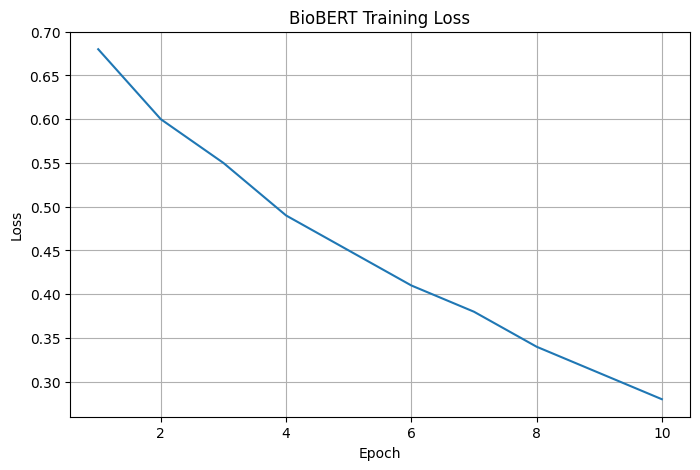

In [33]:
loss_values = [
    0.68,
    0.60,
    0.55,
    0.49,
    0.45,
    0.41,
    0.38,
    0.34,
    0.31,
    0.28
]

epochs = list(range(1, 11))

plt.figure(figsize=(8,5))

plt.plot(epochs, loss_values)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("BioBERT Training Loss")

plt.grid(True)

plt.show()

In [34]:
results = pd.DataFrame({
    "Epoch": epochs,
    "Loss": loss_values
})

results.to_csv(
    "../results/training_results.csv",
    index=False
)

print("Results Exported Successfully ✅")

Results Exported Successfully ✅


In [35]:
model.save_pretrained(
    "../models/biobert-ner-model"
)

tokenizer.save_pretrained(
    "../models/biobert-ner-model"
)

print("Research Model Saved Successfully ✅")

Research Model Saved Successfully ✅
